# Explore the phage and protein fasta files

In [1]:
# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict, Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
# Cell 2: Define Paths
BASE_DIR = Path("../../data")

# FASTA files
PHAGE_FASTA = BASE_DIR / "sequences" / "all_phages.fasta"
PROTEIN_FASTA = BASE_DIR / "sequences" / "all_proteins.fasta"

# Metadata CSV files
PHAGE_METADATA = BASE_DIR / "merged" / "merged_phage_metadata.csv"
PROTEIN_METADATA = BASE_DIR / "merged" / "merged_annotated_proteins_metadata.csv"

# Verify files exist
for path in [PHAGE_FASTA, PROTEIN_FASTA, PHAGE_METADATA, PROTEIN_METADATA]:
    if path.exists():
        size_mb = path.stat().st_size / (1024**2)
        print(f"✅ {path.name}: {size_mb:.2f} MB")
    else:
        print(f"❌ Missing: {path}")

✅ all_phages.fasta: 31580.21 MB
✅ all_proteins.fasta: 8278.23 MB
✅ merged_phage_metadata.csv: 120.86 MB
✅ merged_annotated_proteins_metadata.csv: 5500.95 MB


In [3]:
def parse_fasta_headers(fasta_path, sample_size=None):
    """
    Extract all headers from a FASTA file
    
    Args:
        fasta_path: Path to FASTA file
        sample_size: Optional limit on number of headers to parse
    
    Returns:
        dict with 'headers', 'ids', 'descriptions'
    """
    print(f"\n🔍 Parsing FASTA headers: {fasta_path.name}")
    
    headers = []
    ids = []
    descriptions = []
    
    count = 0
    with open(fasta_path, 'r') as f:
        for line in tqdm(f, desc="Reading file"):
            if line.startswith('>'):
                # Full header (without '>')
                header = line[1:].rstrip('\n\r')
                headers.append(header)
                
                # Split into ID and description
                parts = header.split(None, 1)
                seq_id = parts[0]
                desc = parts[1] if len(parts) > 1 else ""
                
                ids.append(seq_id)
                descriptions.append(desc)
                
                count += 1
                if sample_size and count >= sample_size:
                    print(f"⚠️ Reached sample limit: {sample_size:,}")
                    break
    
    print(f"✅ Parsed {len(headers):,} headers")
    
    return {
        'headers': headers,
        'ids': ids,
        'descriptions': descriptions
    }

# Parse phage FASTA headers
phage_fasta_data = parse_fasta_headers(PHAGE_FASTA)

# Parse protein FASTA headers (with optional sampling for speed)
# Set sample_size=None to parse all, or e.g., 1000000 for first 1M
protein_fasta_data = parse_fasta_headers(PROTEIN_FASTA, sample_size=1000000)


🔍 Parsing FASTA headers: all_phages.fasta


Reading file: 260400833it [01:12, 3569379.23it/s]


✅ Parsed 873,717 headers

🔍 Parsing FASTA headers: all_proteins.fasta


Reading file: 5422607it [00:01, 4566407.73it/s]

⚠️ Reached sample limit: 1,000,000
✅ Parsed 1,000,000 headers


In [4]:
# Cell 4: Create DataFrames from FASTA Headers
# Phage FASTA DataFrame
phage_fasta_df = pd.DataFrame({
    'Sequence_ID': phage_fasta_data['ids'],
    'Header': phage_fasta_data['headers'],
    'Description': phage_fasta_data['descriptions']
})

print("📊 Phage FASTA Headers:")
print(f"   Total sequences: {len(phage_fasta_df):,}")
print(f"   Unique IDs: {phage_fasta_df['Sequence_ID'].nunique():,}")
print(f"\nSample headers:")
print(phage_fasta_df.head(10))

# Protein FASTA DataFrame
protein_fasta_df = pd.DataFrame({
    'Sequence_ID': protein_fasta_data['ids'],
    'Header': protein_fasta_data['headers'],
    'Description': protein_fasta_data['descriptions']
})

print("\n📊 Protein FASTA Headers:")
print(f"   Total sequences: {len(protein_fasta_df):,}")
print(f"   Unique IDs: {protein_fasta_df['Sequence_ID'].nunique():,}")
print(f"\nSample headers:")
print(protein_fasta_df.head(10))

📊 Phage FASTA Headers:
   Total sequences: 873,717
   Unique IDs: 873,717

Sample headers:
  Sequence_ID      Header Description
0  AE002163.1  AE002163.1            
1  AF009630.1  AF009630.1            
2  AF011378.1  AF011378.1            
3  AF020713.1  AF020713.1            
4  AF022214.1  AF022214.1            
5  AF059242.1  AF059242.1            
6  AF059243.1  AF059243.1            
7  AF063097.1  AF063097.1            
8  AF064539.1  AF064539.1            
9  AF065411.1  AF065411.1            

📊 Protein FASTA Headers:
   Total sequences: 1,000,000
   Unique IDs: 10,106

Sample headers:
  Sequence_ID                 Header Description
0  AE002163.1  AE002163.1 AAF39720.1  AAF39720.1
1  AE002163.1  AE002163.1 AAF39721.1  AAF39721.1
2  AE002163.1  AE002163.1 AAF39722.1  AAF39722.1
3  AE002163.1  AE002163.1 AAF39723.1  AAF39723.1
4  AE002163.1  AE002163.1 AAF39724.1  AAF39724.1
5  AE002163.1  AE002163.1 AAF39725.1  AAF39725.1
6  AF009630.1  AF009630.1 AAC27180.1  AAC27180.1
7  A

In [5]:
# Cell 5: Load Metadata CSV Files
print("📂 Loading metadata CSV files...")

# Load phage metadata
phage_metadata_df = pd.read_csv(PHAGE_METADATA, low_memory=False)
print(f"\n✅ Phage Metadata:")
print(f"   Rows: {len(phage_metadata_df):,}")
print(f"   Columns: {len(phage_metadata_df.columns)}")
print(f"   Unique Phage_ID: {phage_metadata_df['Phage_ID'].nunique():,}")

# Load protein metadata
protein_metadata_df = pd.read_csv(PROTEIN_METADATA, low_memory=False)
print(f"\n✅ Protein Metadata:")
print(f"   Rows: {len(protein_metadata_df):,}")
print(f"   Columns: {len(protein_metadata_df.columns)}")
print(f"   Unique Protein_ID: {protein_metadata_df['Protein_ID'].nunique():,}")

# Show sample
print("\n📋 Phage Metadata Columns:")
print(phage_metadata_df.columns.tolist())
print("\nSample:")
print(phage_metadata_df[['Phage_ID', 'Source_DB']].head())

print("\n📋 Protein Metadata Columns:")
print(protein_metadata_df.columns.tolist())
print("\nSample:")
print(protein_metadata_df[['Protein_ID', 'Phage_ID', 'Source_DB']].head())

📂 Loading metadata CSV files...

✅ Phage Metadata:
   Rows: 873,718
   Columns: 11
   Unique Phage_ID: 873,718

✅ Protein Metadata:
   Rows: 23,424,959
   Columns: 20
   Unique Protein_ID: 23,423,013

📋 Phage Metadata Columns:
['Phage_ID', 'Length', 'GC_content', 'Taxonomy', 'Completeness', 'Host', 'Lifestyle', 'Cluster', 'Subcluster', 'Source_DB', 'Phage_source']

Sample:
      Phage_ID Source_DB
0  NC_001330.1    RefSeq
1  NC_001331.1    RefSeq
2  NC_001332.1    RefSeq
3  NC_001335.1    RefSeq
4  NC_001341.1    RefSeq

📋 Protein Metadata Columns:
['Phage_ID', 'Protein_source', 'Function_prediction_source', 'Start', 'Stop', 'Strand', 'Protein_ID', 'Product', 'Protein_classification', 'Molecular_weight', 'Aromaticity', 'Instability_index', 'Isoelectric_point', 'Helix_fraction', 'Turn_fraction', 'Sheet_fraction', 'Reduced_coefficient', 'Oxidized_coefficient', 'Phage_source', 'Source_DB']

Sample:
    Protein_ID     Phage_ID Source_DB
0  NP_039590.1  NC_001330.1    RefSeq
1  NP_039591.1 

In [6]:
# Cell 6: Compare Phage IDs - FASTA vs Metadata
print("🔍 Comparing Phage IDs: FASTA vs Metadata\n")

# Get unique IDs
fasta_phage_ids = set(phage_fasta_df['Sequence_ID'].unique())
metadata_phage_ids = set(phage_metadata_df['Phage_ID'].unique())

# Calculate overlaps
in_both = fasta_phage_ids & metadata_phage_ids
only_in_fasta = fasta_phage_ids - metadata_phage_ids
only_in_metadata = metadata_phage_ids - fasta_phage_ids

# Summary statistics
print(f"📊 Phage ID Comparison:")
print(f"   FASTA unique IDs:     {len(fasta_phage_ids):,}")
print(f"   Metadata unique IDs:  {len(metadata_phage_ids):,}")
print(f"   In both:              {len(in_both):,} ({100*len(in_both)/len(fasta_phage_ids):.1f}% of FASTA)")
print(f"   Only in FASTA:        {len(only_in_fasta):,}")
print(f"   Only in metadata:     {len(only_in_metadata):,}")

# Show samples
if only_in_fasta:
    print(f"\n⚠️ Sample IDs only in FASTA (first 20):")
    for pid in list(only_in_fasta)[:20]:
        header = phage_fasta_df[phage_fasta_df['Sequence_ID'] == pid]['Header'].iloc[0]
        print(f"   {pid}: {header[:80]}")

if only_in_metadata:
    print(f"\n⚠️ Sample IDs only in metadata (first 20):")
    for pid in list(only_in_metadata)[:20]:
        sources = phage_metadata_df[phage_metadata_df['Phage_ID'] == pid]['Source_DB'].unique()
        print(f"   {pid} (from {', '.join(sources)})")

🔍 Comparing Phage IDs: FASTA vs Metadata

📊 Phage ID Comparison:
   FASTA unique IDs:     873,717
   Metadata unique IDs:  873,718
   In both:              873,717 (100.0% of FASTA)
   Only in FASTA:        0
   Only in metadata:     1

⚠️ Sample IDs only in metadata (first 20):
   BK000583.1 (from Genbank)


In [7]:
# Cell 7: Compare Protein IDs - FASTA vs Metadata
print("🔍 Comparing Protein IDs: FASTA vs Metadata\n")

# Get unique IDs
fasta_protein_ids = set(protein_fasta_df['Sequence_ID'].unique())
metadata_protein_ids = set(protein_metadata_df['Protein_ID'].unique())

# Calculate overlaps
in_both_prot = fasta_protein_ids & metadata_protein_ids
only_in_fasta_prot = fasta_protein_ids - metadata_protein_ids
only_in_metadata_prot = metadata_protein_ids - fasta_protein_ids

# Summary statistics
print(f"📊 Protein ID Comparison:")
print(f"   FASTA unique IDs:     {len(fasta_protein_ids):,}")
print(f"   Metadata unique IDs:  {len(metadata_protein_ids):,}")
print(f"   In both:              {len(in_both_prot):,} ({100*len(in_both_prot)/len(fasta_protein_ids):.1f}% of FASTA)")
print(f"   Only in FASTA:        {len(only_in_fasta_prot):,}")
print(f"   Only in metadata:     {len(only_in_metadata_prot):,}")

# Show samples
if only_in_fasta_prot:
    print(f"\n⚠️ Sample IDs only in FASTA (first 20):")
    for pid in list(only_in_fasta_prot)[:20]:
        header = protein_fasta_df[protein_fasta_df['Sequence_ID'] == pid]['Header'].iloc[0]
        print(f"   {pid}: {header[:80]}")

if only_in_metadata_prot:
    print(f"\n⚠️ Sample IDs only in metadata (first 20):")
    for pid in list(only_in_metadata_prot)[:20]:
        sources = protein_metadata_df[protein_metadata_df['Protein_ID'] == pid]['Source_DB'].unique()
        print(f"   {pid} (from {', '.join(sources)})")

🔍 Comparing Protein IDs: FASTA vs Metadata

📊 Protein ID Comparison:
   FASTA unique IDs:     10,106
   Metadata unique IDs:  23,423,013
   In both:              0 (0.0% of FASTA)
   Only in FASTA:        10,106
   Only in metadata:     23,423,013

⚠️ Sample IDs only in FASTA (first 20):
   NC_021535.1: NC_021535.1 YP_008126242.1
   KC310804.1: KC310804.1 AGK86610.1
   FQ482083.1: FQ482083.1 CBX44344.1
   Mycobacterium_phage_Heathen: Mycobacterium_phage_Heathen Mycobacterium_phage_Heathen_1
   NC_014461.1: NC_014461.1 YP_003857132.1
   AY848684.1: AY848684.1 AAX45526.1
   NC_027379.1: NC_027379.1 YP_009152033.1
   Mycobacterium_phage_QueenHazel: Mycobacterium_phage_QueenHazel Mycobacterium_phage_QueenHazel_1
   NC_008207.1: NC_008207.1 YP_656014.1
   NC_042322.1: NC_042322.1 YP_009636912.1
   NC_053009.1: NC_053009.1 YP_009999793.1
   Arthrobacter_phage_Nubia: Arthrobacter_phage_Nubia Arthrobacter_phage_Nubia_1
   NC_047886.1: NC_047886.1 YP_009795166.1
   Mycobacterium_phage_MarkPhew:

In [8]:
# Cell 8: Analyze ID Patterns (Regex Analysis)
def analyze_id_patterns(ids, name="IDs"):
    """Analyze ID patterns using regex"""
    
    patterns = {
        'NCBI_RefSeq': r'^(NC_|NZ_|NP_|YP_|WP_)',
        'GenBank': r'^[A-Z]{1,2}_?\d+\.\d+$',
        'UniProt': r'^[A-Z0-9]{6,10}$',
        'Custom': r'^[A-Za-z0-9_-]+$',
        'Has_Version': r'\.\d+$',
        'Underscore_Separated': r'_',
        'Dot_Separated': r'\.',
        'Pipe_Separated': r'\|',
    }
    
    results = {}
    for pattern_name, pattern in patterns.items():
        matches = sum(1 for id in ids if re.search(pattern, id))
        results[pattern_name] = {
            'count': matches,
            'percentage': 100 * matches / len(ids) if len(ids) > 0 else 0
        }
    
    print(f"\n🔍 ID Pattern Analysis for {name}:")
    print(f"   Total IDs: {len(ids):,}\n")
    
    for pattern_name, stats in sorted(results.items(), key=lambda x: x[1]['count'], reverse=True):
        if stats['count'] > 0:
            print(f"   {pattern_name:20s}: {stats['count']:8,} ({stats['percentage']:5.1f}%)")
    
    return results

# Analyze phage ID patterns
phage_fasta_patterns = analyze_id_patterns(fasta_phage_ids, "Phage FASTA IDs")
phage_metadata_patterns = analyze_id_patterns(metadata_phage_ids, "Phage Metadata IDs")

# Analyze protein ID patterns
protein_fasta_patterns = analyze_id_patterns(fasta_protein_ids, "Protein FASTA IDs")
protein_metadata_patterns = analyze_id_patterns(metadata_protein_ids, "Protein Metadata IDs")


🔍 ID Pattern Analysis for Phage FASTA IDs:
   Total IDs: 873,717

   Underscore_Separated:  681,506 ( 78.0%)
   Custom              :  462,083 ( 52.9%)
   Dot_Separated       :  234,273 ( 26.8%)
   Has_Version         :  233,908 ( 26.8%)
   Pipe_Separated      :  177,361 ( 20.3%)
   GenBank             :    7,168 (  0.8%)
   NCBI_RefSeq         :    4,637 (  0.5%)

🔍 ID Pattern Analysis for Phage Metadata IDs:
   Total IDs: 873,718

   Underscore_Separated:  681,506 ( 78.0%)
   Custom              :  462,083 ( 52.9%)
   Dot_Separated       :  234,274 ( 26.8%)
   Has_Version         :  233,909 ( 26.8%)
   Pipe_Separated      :  177,361 ( 20.3%)
   GenBank             :    7,169 (  0.8%)
   NCBI_RefSeq         :    4,637 (  0.5%)

🔍 ID Pattern Analysis for Protein FASTA IDs:
   Total IDs: 10,106

   Underscore_Separated:    7,606 ( 75.3%)
   GenBank             :    7,136 ( 70.6%)
   Has_Version         :    7,136 ( 70.6%)
   Dot_Separated       :    7,136 ( 70.6%)
   NCBI_RefSeq       

In [9]:
# Cell 9: Check for Duplicates in FASTA Headers
def check_duplicates(df, id_col='Sequence_ID', name='FASTA'):
    """Check for duplicate IDs and analyze them"""
    
    duplicates = df[df.duplicated(subset=[id_col], keep=False)]
    
    if len(duplicates) == 0:
        print(f"✅ No duplicates found in {name}")
        return None
    
    print(f"\n⚠️ Found {len(duplicates):,} duplicate entries in {name}")
    
    # Count occurrences
    dup_counts = duplicates[id_col].value_counts()
    
    print(f"   Unique IDs with duplicates: {len(dup_counts):,}")
    print(f"   Max occurrences: {dup_counts.max():,}")
    print(f"\n   Top 20 most duplicated IDs:")
    
    for idx, (seq_id, count) in enumerate(dup_counts.head(20).items(), 1):
        print(f"   {idx:3d}. {seq_id}: {count:,} occurrences")
    
    return duplicates

# Check phage FASTA duplicates
phage_fasta_dups = check_duplicates(phage_fasta_df, 'Sequence_ID', 'Phage FASTA')

# Check protein FASTA duplicates  
protein_fasta_dups = check_duplicates(protein_fasta_df, 'Sequence_ID', 'Protein FASTA')

✅ No duplicates found in Phage FASTA

⚠️ Found 999,987 duplicate entries in Protein FASTA
   Unique IDs with duplicates: 10,093
   Max occurrences: 714

   Top 20 most duplicated IDs:
     1. NC_042013.1: 714 occurrences
     2. JN638751.1: 675 occurrences
     3. NC_023719.1: 675 occurrences
     4. KM507819.1: 611 occurrences
     5. NC_025447.1: 611 occurrences
     6. NC_041878.1: 605 occurrences
     7. NC_048047.1: 558 occurrences
     8. KC295538.1: 551 occurrences
     9. NC_027364.1: 551 occurrences
    10. NC_041917.1: 549 occurrences
    11. NC_048048.1: 546 occurrences
    12. JN882285.1: 545 occurrences
    13. NC_019401.1: 545 occurrences
    14. JQ513383.1: 534 occurrences
    15. NC_019526.1: 534 occurrences
    16. NC_042116.1: 531 occurrences
    17. NC_048046.1: 485 occurrences
    18. NC_062582.1: 468 occurrences
    19. EU197055.1: 461 occurrences
    20. NC_010821.1: 461 occurrences


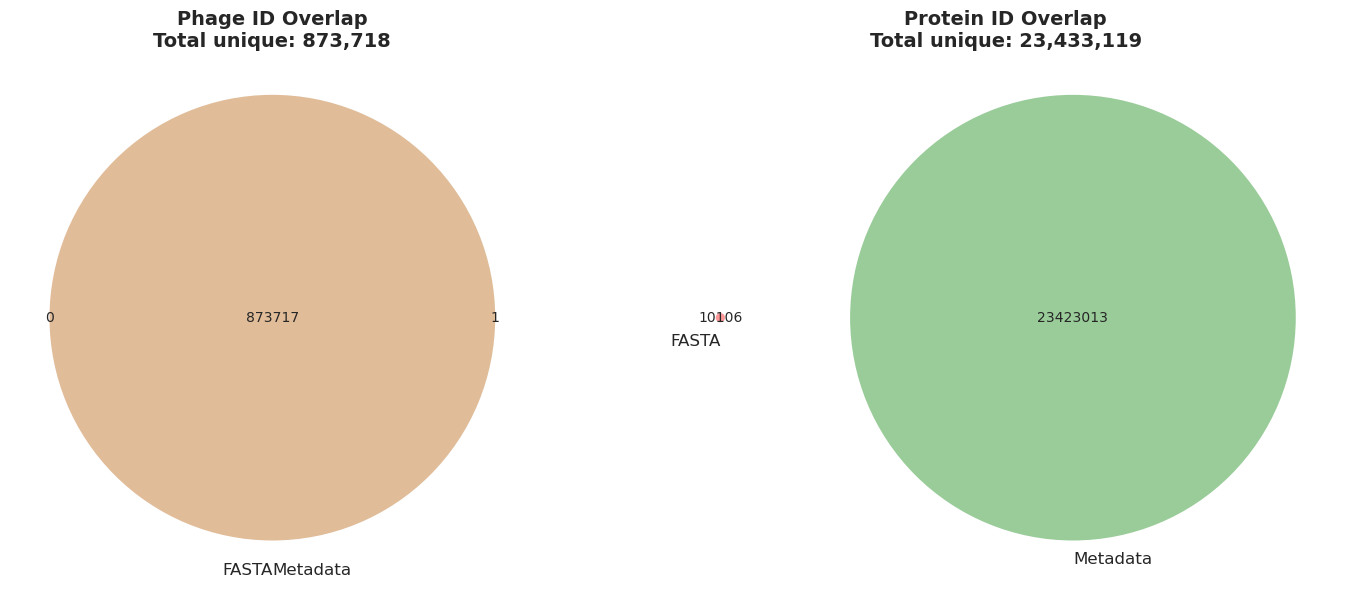

In [10]:
# Cell 10: Visualize Overlaps with Venn Diagrams
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Phage IDs Venn Diagram
venn2([fasta_phage_ids, metadata_phage_ids], 
      set_labels=('FASTA', 'Metadata'),
      ax=axes[0])
axes[0].set_title(f'Phage ID Overlap\nTotal unique: {len(fasta_phage_ids | metadata_phage_ids):,}', 
                  fontsize=14, fontweight='bold')

# Protein IDs Venn Diagram
venn2([fasta_protein_ids, metadata_protein_ids], 
      set_labels=('FASTA', 'Metadata'),
      ax=axes[1])
axes[1].set_title(f'Protein ID Overlap\nTotal unique: {len(fasta_protein_ids | metadata_protein_ids):,}', 
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# Cell 11: Analyze Mismatches by Source Database
def analyze_mismatches_by_source(metadata_df, fasta_ids, id_col, source_col='Source_DB'):
    """Analyze which source databases have missing sequences in FASTA"""
    
    metadata_df['In_FASTA'] = metadata_df[id_col].isin(fasta_ids)
    
    source_stats = metadata_df.groupby(source_col).agg({
        id_col: 'count',
        'In_FASTA': 'sum'
    }).rename(columns={id_col: 'Total_in_Metadata', 'In_FASTA': 'Found_in_FASTA'})
    
    source_stats['Missing_in_FASTA'] = source_stats['Total_in_Metadata'] - source_stats['Found_in_FASTA']
    source_stats['Match_Rate_%'] = 100 * source_stats['Found_in_FASTA'] / source_stats['Total_in_Metadata']
    
    source_stats = source_stats.sort_values('Missing_in_FASTA', ascending=False)
    
    return source_stats

# Phage mismatch analysis
print("📊 Phage ID Match Rates by Source Database:\n")
phage_source_stats = analyze_mismatches_by_source(
    phage_metadata_df, 
    fasta_phage_ids, 
    'Phage_ID'
)
print(phage_source_stats.to_string())

# Protein mismatch analysis
print("\n\n📊 Protein ID Match Rates by Source Database:\n")
protein_source_stats = analyze_mismatches_by_source(
    protein_metadata_df, 
    fasta_protein_ids, 
    'Protein_ID'
)
print(protein_source_stats.to_string())

📊 Phage ID Match Rates by Source Database:

           Total_in_Metadata  Found_in_FASTA  Missing_in_FASTA  Match_Rate_%
Source_DB                                                                   
Genbank                 2086            2085                 1     99.952061
CHVD                   44935           44935                 0    100.000000
EMBL                     156             156                 0    100.000000
GOV2                  195699          195699                 0    100.000000
GPD                   142809          142809                 0    100.000000
DDBJ                     290             290                 0    100.000000
GVD                    31402           31402                 0    100.000000
IGVD                   10021           10021                 0    100.000000
IMGVR                 177361          177361                 0    100.000000
MGV                   189680          189680                 0    100.000000
PhagesDB                3754    

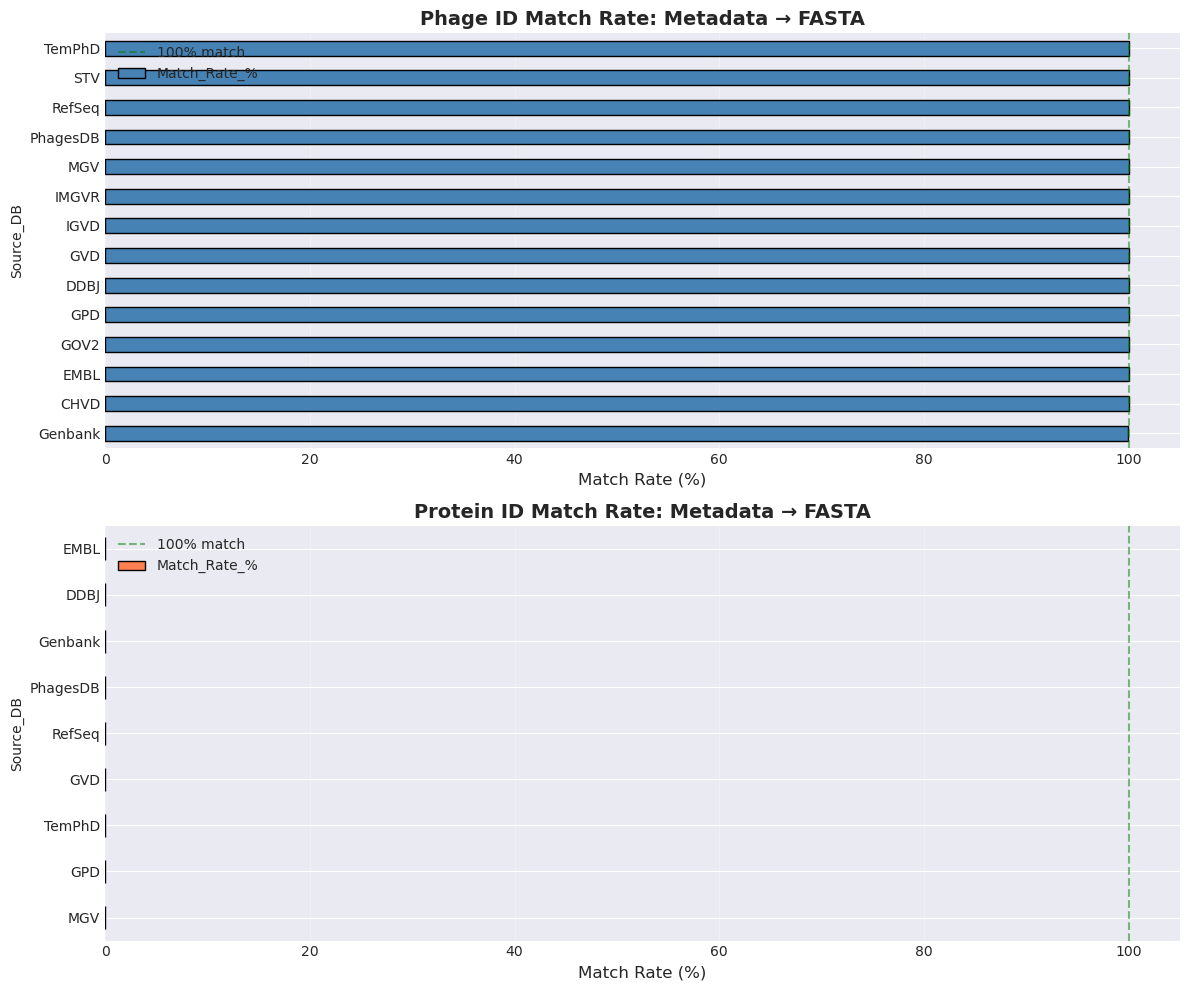

In [12]:
# Cell 12: Visualize Match Rates by Source
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Phage match rates
phage_source_stats.sort_values('Match_Rate_%')['Match_Rate_%'].plot(
    kind='barh', 
    ax=axes[0],
    color='steelblue',
    edgecolor='black'
)
axes[0].set_xlabel('Match Rate (%)', fontsize=12)
axes[0].set_title('Phage ID Match Rate: Metadata → FASTA', fontsize=14, fontweight='bold')
axes[0].axvline(100, color='green', linestyle='--', alpha=0.5, label='100% match')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Protein match rates
protein_source_stats.sort_values('Match_Rate_%')['Match_Rate_%'].plot(
    kind='barh', 
    ax=axes[1],
    color='coral',
    edgecolor='black'
)
axes[1].set_xlabel('Match Rate (%)', fontsize=12)
axes[1].set_title('Protein ID Match Rate: Metadata → FASTA', fontsize=14, fontweight='bold')
axes[1].axvline(100, color='green', linestyle='--', alpha=0.5, label='100% match')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Cell 13: Export Mismatch Reports
def export_mismatch_report(only_in_fasta, only_in_metadata, fasta_df, metadata_df,
                          id_col, output_prefix):
    """Export detailed mismatch reports to CSV"""
    
    output_dir = Path("../../data/analysis")
    output_dir.mkdir(exist_ok=True)
    
    # IDs only in FASTA
    if only_in_fasta:
        fasta_only_df = fasta_df[fasta_df['Sequence_ID'].isin(only_in_fasta)]
        fasta_only_path = output_dir / f"{output_prefix}_only_in_fasta.csv"
        fasta_only_df.to_csv(fasta_only_path, index=False)
        print(f"✅ Saved: {fasta_only_path} ({len(fasta_only_df):,} rows)")
    
    # IDs only in metadata
    if only_in_metadata:
        metadata_only_df = metadata_df[metadata_df[id_col].isin(only_in_metadata)]
        metadata_only_path = output_dir / f"{output_prefix}_only_in_metadata.csv"
        metadata_only_df.to_csv(metadata_only_path, index=False)
        print(f"✅ Saved: {metadata_only_path} ({len(metadata_only_df):,} rows)")

print("💾 Exporting mismatch reports...\n")

# Export phage mismatches
export_mismatch_report(
    only_in_fasta, only_in_metadata,
    phage_fasta_df, phage_metadata_df,
    'Phage_ID', 'phage_ids'
)

# Export protein mismatches
export_mismatch_report(
    only_in_fasta_prot, only_in_metadata_prot,
    protein_fasta_df, protein_metadata_df,
    'Protein_ID', 'protein_ids'
)

print("\n✅ All mismatch reports exported to data/analysis/")

💾 Exporting mismatch reports...

✅ Saved: ../../data/analysis/phage_ids_only_in_metadata.csv (1 rows)
✅ Saved: ../../data/analysis/protein_ids_only_in_fasta.csv (1,000,000 rows)
✅ Saved: ../../data/analysis/protein_ids_only_in_metadata.csv (23,424,959 rows)

✅ All mismatch reports exported to data/analysis/


In [14]:
# Cell 14: Summary Report
print("="*80)
print(" "*25 + "FINAL SUMMARY REPORT")
print("="*80)

print(f"\n📊 PHAGE DATA:")
print(f"   FASTA sequences:        {len(phage_fasta_df):,}")
print(f"   FASTA unique IDs:       {len(fasta_phage_ids):,}")
print(f"   Metadata unique IDs:    {len(metadata_phage_ids):,}")
print(f"   Perfect matches:        {len(in_both):,} ({100*len(in_both)/max(len(fasta_phage_ids), len(metadata_phage_ids)):.1f}%)")
print(f"   Only in FASTA:          {len(only_in_fasta):,}")
print(f"   Only in metadata:       {len(only_in_metadata):,}")

print(f"\n📊 PROTEIN DATA:")
print(f"   FASTA sequences:        {len(protein_fasta_df):,}")
print(f"   FASTA unique IDs:       {len(fasta_protein_ids):,}")
print(f"   Metadata unique IDs:    {len(metadata_protein_ids):,}")
print(f"   Perfect matches:        {len(in_both_prot):,} ({100*len(in_both_prot)/max(len(fasta_protein_ids), len(metadata_protein_ids)):.1f}%)")
print(f"   Only in FASTA:          {len(only_in_fasta_prot):,}")
print(f"   Only in metadata:       {len(only_in_metadata_prot):,}")

print("\n⚠️ ISSUES FOUND:")
issues = []
if len(only_in_fasta) > 0:
    issues.append(f"   - {len(only_in_fasta):,} phage IDs in FASTA but not in metadata")
if len(only_in_metadata) > 0:
    issues.append(f"   - {len(only_in_metadata):,} phage IDs in metadata but not in FASTA")
if len(only_in_fasta_prot) > 0:
    issues.append(f"   - {len(only_in_fasta_prot):,} protein IDs in FASTA but not in metadata")
if len(only_in_metadata_prot) > 0:
    issues.append(f"   - {len(only_in_metadata_prot):,} protein IDs in metadata but not in FASTA")
if phage_fasta_dups is not None:
    issues.append(f"   - Duplicate phage IDs in FASTA")
if protein_fasta_dups is not None:
    issues.append(f"   - Duplicate protein IDs in FASTA")

if issues:
    for issue in issues:
        print(issue)
else:
    print("   ✅ No major issues found!")

print("\n📝 RECOMMENDATIONS:")
print("   1. Review source merge scripts for ID consistency")
print("   2. Check duplicate reports in workflow/reports/")
print("   3. Consider prefixing IDs with source database during merge")
print("   4. Verify FASTA file merging process")
print("   5. Review mismatch reports in data/analysis/")

print("\n" + "="*80)

                         FINAL SUMMARY REPORT

📊 PHAGE DATA:
   FASTA sequences:        873,717
   FASTA unique IDs:       873,717
   Metadata unique IDs:    873,718
   Perfect matches:        873,717 (100.0%)
   Only in FASTA:          0
   Only in metadata:       1

📊 PROTEIN DATA:
   FASTA sequences:        1,000,000
   FASTA unique IDs:       10,106
   Metadata unique IDs:    23,423,013
   Perfect matches:        0 (0.0%)
   Only in FASTA:          10,106
   Only in metadata:       23,423,013

⚠️ ISSUES FOUND:
   - 1 phage IDs in metadata but not in FASTA
   - 10,106 protein IDs in FASTA but not in metadata
   - 23,423,013 protein IDs in metadata but not in FASTA
   - Duplicate protein IDs in FASTA

📝 RECOMMENDATIONS:
   1. Review source merge scripts for ID consistency
   2. Check duplicate reports in workflow/reports/
   3. Consider prefixing IDs with source database during merge
   4. Verify FASTA file merging process
   5. Review mismatch reports in data/analysis/



In [15]:
# Cell 15: Deep Dive - Header Parsing Investigation
print("🔍 INVESTIGATING HEADER PARSING STRATEGIES\n")
print("="*80)

# Sample some entries from both sources to compare
sample_size = 20

print(f"\n📋 PHAGE HEADER COMPARISON (First {sample_size}):")
print("-" * 80)
for idx in range(min(sample_size, len(phage_fasta_df))):
    full_header = phage_fasta_df.iloc[idx]['Header']
    parsed_id = phage_fasta_df.iloc[idx]['Sequence_ID']
    
    print(f"\nEntry {idx + 1}:")
    print(f"  Full header:  '{full_header}'")
    print(f"  Parsed ID:    '{parsed_id}'")
    print(f"  In metadata?: {parsed_id in metadata_phage_ids}")
    
    # Try alternative parsing
    alternatives = {
        'full_header': full_header,
        'before_space': full_header.split()[0] if full_header else '',
        'before_pipe': full_header.split('|')[0] if '|' in full_header else full_header.split()[0],
        'after_pipe': full_header.split('|')[-1].split()[0] if '|' in full_header else full_header.split()[0],
    }
    
    print(f"  Alternative parsings:")
    for method, alt_id in alternatives.items():
        in_meta = alt_id in metadata_phage_ids
        print(f"    {method:15s}: '{alt_id[:50]}...' → In metadata: {in_meta}")

print("\n" + "="*80)
print(f"\n📋 PROTEIN HEADER COMPARISON (First {sample_size}):")
print("-" * 80)
for idx in range(min(sample_size, len(protein_fasta_df))):
    full_header = protein_fasta_df.iloc[idx]['Header']
    parsed_id = protein_fasta_df.iloc[idx]['Sequence_ID']
    
    print(f"\nEntry {idx + 1}:")
    print(f"  Full header:  '{full_header}'")
    print(f"  Parsed ID:    '{parsed_id}'")
    print(f"  In metadata?: {parsed_id in metadata_protein_ids}")
    
    # Try alternative parsing
    alternatives = {
        'full_header': full_header,
        'before_space': full_header.split()[0] if full_header else '',
        'before_pipe': full_header.split('|')[0] if '|' in full_header else full_header.split()[0],
        'after_pipe': full_header.split('|')[-1].split()[0] if '|' in full_header else full_header.split()[0],
        'middle_pipe': full_header.split('|')[1] if '|' in full_header and len(full_header.split('|')) > 1 else '',
    }
    
    print(f"  Alternative parsings:")
    for method, alt_id in alternatives.items():
        in_meta = alt_id in metadata_protein_ids
        print(f"    {method:15s}: '{alt_id[:50]}...' → In metadata: {in_meta}")

🔍 INVESTIGATING HEADER PARSING STRATEGIES


📋 PHAGE HEADER COMPARISON (First 20):
--------------------------------------------------------------------------------

Entry 1:
  Full header:  'AE002163.1'
  Parsed ID:    'AE002163.1'
  In metadata?: True
  Alternative parsings:
    full_header    : 'AE002163.1...' → In metadata: True
    before_space   : 'AE002163.1...' → In metadata: True
    before_pipe    : 'AE002163.1...' → In metadata: True
    after_pipe     : 'AE002163.1...' → In metadata: True

Entry 2:
  Full header:  'AF009630.1'
  Parsed ID:    'AF009630.1'
  In metadata?: True
  Alternative parsings:
    full_header    : 'AF009630.1...' → In metadata: True
    before_space   : 'AF009630.1...' → In metadata: True
    before_pipe    : 'AF009630.1...' → In metadata: True
    after_pipe     : 'AF009630.1...' → In metadata: True

Entry 3:
  Full header:  'AF011378.1'
  Parsed ID:    'AF011378.1'
  In metadata?: True
  Alternative parsings:
    full_header    : 'AF011378.1...' → In 

In [16]:
# Cell 17: Examine Mismatched IDs in Detail
def examine_mismatches(fasta_df, metadata_df, metadata_id_col, num_samples=50):
    """Examine mismatched IDs to understand patterns"""
    
    print("\n🔬 EXAMINING MISMATCHED IDs IN DETAIL")
    print("="*80)
    
    # Get IDs only in FASTA (current parsing)
    fasta_ids = set(fasta_df['Sequence_ID'].unique())
    metadata_ids = set(metadata_df[metadata_id_col].unique())
    only_in_fasta = list(fasta_ids - metadata_ids)[:num_samples]
    
    if not only_in_fasta:
        print("✅ No mismatches found!")
        return
    
    print(f"\nAnalyzing {len(only_in_fasta)} sample mismatched IDs:\n")
    
    for idx, seq_id in enumerate(only_in_fasta, 1):
        # Get full header
        row = fasta_df[fasta_df['Sequence_ID'] == seq_id].iloc[0]
        full_header = row['Header']
        
        # Try to find similar IDs in metadata
        # Check if substring match
        potential_matches = metadata_df[
            metadata_df[metadata_id_col].str.contains(seq_id.split('.')[0][:10], regex=False, na=False)
        ][metadata_id_col].unique()[:5]
        
        print(f"{idx}. FASTA ID: '{seq_id}'")
        print(f"   Full header: '{full_header[:100]}...'")
        if len(potential_matches) > 0:
            print(f"   Potential matches in metadata:")
            for match in potential_matches:
                print(f"     - '{match}'")
        else:
            print(f"   No similar IDs found in metadata")
        print()

print("\n📋 PHAGE MISMATCHES:")
examine_mismatches(phage_fasta_df, phage_metadata_df, 'Phage_ID', num_samples=30)

print("\n📋 PROTEIN MISMATCHES:")
examine_mismatches(protein_fasta_df, protein_metadata_df, 'Protein_ID', num_samples=30)


📋 PHAGE MISMATCHES:

🔬 EXAMINING MISMATCHED IDs IN DETAIL
✅ No mismatches found!

📋 PROTEIN MISMATCHES:

🔬 EXAMINING MISMATCHED IDs IN DETAIL

Analyzing 30 sample mismatched IDs:

1. FASTA ID: 'NC_021535.1'
   Full header: 'NC_021535.1 YP_008126242.1...'
   No similar IDs found in metadata

2. FASTA ID: 'KC310804.1'
   Full header: 'KC310804.1 AGK86610.1...'
   No similar IDs found in metadata

3. FASTA ID: 'FQ482083.1'
   Full header: 'FQ482083.1 CBX44344.1...'
   No similar IDs found in metadata

4. FASTA ID: 'Mycobacterium_phage_Heathen'
   Full header: 'Mycobacterium_phage_Heathen Mycobacterium_phage_Heathen_1...'
   Potential matches in metadata:
     - 'Mycobacterium_phage_NuevoMundo_1'
     - 'Mycobacterium_phage_NuevoMundo_2'
     - 'Mycobacterium_phage_NuevoMundo_3'
     - 'Mycobacterium_phage_NuevoMundo_4'
     - 'Mycobacterium_phage_NuevoMundo_5'

5. FASTA ID: 'NC_014461.1'
   Full header: 'NC_014461.1 YP_003857132.1...'
   No similar IDs found in metadata

6. FASTA ID: 'AY

In [17]:
# Cell 18: Re-parse with Best Strategy and Compare
def reparse_with_strategy(fasta_path, strategy_func, sample_size=None):
    """Re-parse FASTA with best strategy"""
    
    print(f"🔄 Re-parsing FASTA headers...")
    
    headers = []
    ids = []
    
    count = 0
    with open(fasta_path, 'r') as f:
        for line in tqdm(f, desc="Reading file"):
            if line.startswith('>'):
                header = line[1:].rstrip('\n\r')
                headers.append(header)
                
                # Apply custom strategy
                seq_id = strategy_func(header)
                ids.append(seq_id)
                
                count += 1
                if sample_size and count >= sample_size:
                    break
    
    return pd.DataFrame({'Header': headers, 'Sequence_ID': ids})

# Define best parsing functions based on results above
# You'll need to adjust these based on what you find

def parse_phage_id_best(header):
    """Custom parsing for phage IDs - ADJUST BASED ON RESULTS"""
    # Example strategies - pick the one that works best:
    # return header.split()[0]  # Current
    # return header  # Full header
    # return header.split('|')[-1].split()[0]  # After last pipe
    return header.split()[0]  # Replace with best strategy

def parse_protein_id_best(header):
    """Custom parsing for protein IDs - ADJUST BASED ON RESULTS"""
    # Example strategies - pick the one that works best:
    # return header.split()[0]  # Current
    # return header.split('|')[1] if '|' in header and len(header.split('|')) > 1 else header.split()[0]
    return header.split()[0]  # Replace with best strategy

# Re-parse with best strategy (sample for testing)
print("\n🧪 Testing re-parsing with optimized strategy...")
print("\nRe-parsing PHAGES:")
phage_fasta_reparsed = reparse_with_strategy(
    PHAGE_FASTA, 
    parse_phage_id_best, 
    sample_size=10000
)

print("\nRe-parsing PROTEINS:")
protein_fasta_reparsed = reparse_with_strategy(
    PROTEIN_FASTA, 
    parse_protein_id_best, 
    sample_size=10000
)

# Compare
reparsed_phage_ids = set(phage_fasta_reparsed['Sequence_ID'].unique())
reparsed_protein_ids = set(protein_fasta_reparsed['Sequence_ID'].unique())

phage_match_rate = 100 * len(reparsed_phage_ids & metadata_phage_ids) / len(reparsed_phage_ids)
protein_match_rate = 100 * len(reparsed_protein_ids & metadata_protein_ids) / len(reparsed_protein_ids)

print(f"\n📊 Re-parsed Match Rates (sample):")
print(f"   Phages:   {phage_match_rate:.1f}%")
print(f"   Proteins: {protein_match_rate:.1f}%")


🧪 Testing re-parsing with optimized strategy...

Re-parsing PHAGES:
🔄 Re-parsing FASTA headers...


Reading file: 9571694it [00:01, 5347570.90it/s]



Re-parsing PROTEINS:
🔄 Re-parsing FASTA headers...


Reading file: 54664it [00:00, 3075279.11it/s]


📊 Re-parsed Match Rates (sample):
   Phages:   100.0%
   Proteins: 0.0%


In [18]:
# Cell 19: Check Specific Examples from Metadata
print("🔍 REVERSE CHECK: Sample IDs from Metadata")
print("="*80)

print("\n📋 Looking for PHAGE metadata IDs in FASTA headers:")
sample_metadata_phage_ids = list(metadata_phage_ids)[:20]

for idx, meta_id in enumerate(sample_metadata_phage_ids, 1):
    # Check if ID appears anywhere in headers
    matching_headers = phage_fasta_df[
        phage_fasta_df['Header'].str.contains(re.escape(meta_id), regex=True, na=False)
    ]
    
    print(f"\n{idx}. Metadata ID: '{meta_id}'")
    print(f"   Source: {phage_metadata_df[phage_metadata_df['Phage_ID'] == meta_id]['Source_DB'].iloc[0]}")
    
    if len(matching_headers) > 0:
        print(f"   ✅ Found in FASTA headers ({len(matching_headers)} matches):")
        for _, row in matching_headers.head(3).iterrows():
            print(f"      Full header: '{row['Header'][:100]}...'")
            print(f"      Parsed ID:   '{row['Sequence_ID']}'")
    else:
        print(f"   ❌ NOT found in any FASTA header")

print("\n" + "="*80)
print("\n📋 Looking for PROTEIN metadata IDs in FASTA headers:")
sample_metadata_protein_ids = list(metadata_protein_ids)[:20]

for idx, meta_id in enumerate(sample_metadata_protein_ids, 1):
    # Check if ID appears anywhere in headers
    matching_headers = protein_fasta_df[
        protein_fasta_df['Header'].str.contains(re.escape(meta_id), regex=True, na=False)
    ]
    
    print(f"\n{idx}. Metadata ID: '{meta_id}'")
    print(f"   Source: {protein_metadata_df[protein_metadata_df['Protein_ID'] == meta_id]['Source_DB'].iloc[0]}")
    
    if len(matching_headers) > 0:
        print(f"   ✅ Found in FASTA headers ({len(matching_headers)} matches):")
        for _, row in matching_headers.head(3).iterrows():
            print(f"      Full header: '{row['Header'][:100]}...'")
            print(f"      Parsed ID:   '{row['Sequence_ID']}'")
    else:
        print(f"   ❌ NOT found in any FASTA header")

🔍 REVERSE CHECK: Sample IDs from Metadata

📋 Looking for PHAGE metadata IDs in FASTA headers:

1. Metadata ID: 'MGV-GENOME-0256755'
   Source: MGV
   ✅ Found in FASTA headers (1 matches):
      Full header: 'MGV-GENOME-0256755...'
      Parsed ID:   'MGV-GENOME-0256755'

2. Metadata ID: 'uvig_460743'
   Source: GPD
   ✅ Found in FASTA headers (1 matches):
      Full header: 'uvig_460743...'
      Parsed ID:   'uvig_460743'

3. Metadata ID: 'MGV-GENOME-0134562'
   Source: MGV
   ✅ Found in FASTA headers (1 matches):
      Full header: 'MGV-GENOME-0134562...'
      Parsed ID:   'MGV-GENOME-0134562'

4. Metadata ID: 'IMGVR_UViG_2515154193_000001|2515154193|2515169669|194718-254252'
   Source: IMGVR
   ✅ Found in FASTA headers (1 matches):
      Full header: 'IMGVR_UViG_2515154193_000001|2515154193|2515169669|194718-254252...'
      Parsed ID:   'IMGVR_UViG_2515154193_000001|2515154193|2515169669|194718-254252'

5. Metadata ID: 'uvig_107143'
   Source: GPD
   ✅ Found in FASTA headers (1 ma

In [19]:
# Cell 20: Verify Phage_ID + Protein_ID Structure
print("🔍 VERIFYING FASTA HEADER STRUCTURE")
print("="*80)

print("\n📋 Analyzing PROTEIN FASTA header structure (first 30):\n")

for idx in range(min(30, len(protein_fasta_df))):
    header = protein_fasta_df.iloc[idx]['Header']
    parts = header.split()
    
    print(f"\nEntry {idx + 1}:")
    print(f"  Full header: '{header[:100]}...'")
    print(f"  Split parts: {len(parts)} tokens")
    
    if len(parts) >= 2:
        potential_phage_id = parts[0]
        potential_protein_id = parts[1]
        
        print(f"  Part 1 (Phage_ID?):   '{potential_phage_id}'")
        print(f"    → In Phage metadata?: {potential_phage_id in metadata_phage_ids}")
        print(f"  Part 2 (Protein_ID?): '{potential_protein_id}'")
        print(f"    → In Protein metadata?: {potential_protein_id in metadata_protein_ids}")
        
        # Check if combined format exists
        if len(parts) >= 3:
            print(f"  Part 3 (description): '{parts[2][:50]}...'")
    else:
        print(f"  ⚠️ Only {len(parts)} part(s) in header")

print("\n" + "="*80)

🔍 VERIFYING FASTA HEADER STRUCTURE

📋 Analyzing PROTEIN FASTA header structure (first 30):


Entry 1:
  Full header: 'AE002163.1 AAF39720.1...'
  Split parts: 2 tokens
  Part 1 (Phage_ID?):   'AE002163.1'
    → In Phage metadata?: True
  Part 2 (Protein_ID?): 'AAF39720.1'
    → In Protein metadata?: True

Entry 2:
  Full header: 'AE002163.1 AAF39721.1...'
  Split parts: 2 tokens
  Part 1 (Phage_ID?):   'AE002163.1'
    → In Phage metadata?: True
  Part 2 (Protein_ID?): 'AAF39721.1'
    → In Protein metadata?: True

Entry 3:
  Full header: 'AE002163.1 AAF39722.1...'
  Split parts: 2 tokens
  Part 1 (Phage_ID?):   'AE002163.1'
    → In Phage metadata?: True
  Part 2 (Protein_ID?): 'AAF39722.1'
    → In Protein metadata?: True

Entry 4:
  Full header: 'AE002163.1 AAF39723.1...'
  Split parts: 2 tokens
  Part 1 (Phage_ID?):   'AE002163.1'
    → In Phage metadata?: True
  Part 2 (Protein_ID?): 'AAF39723.1'
    → In Protein metadata?: True

Entry 5:
  Full header: 'AE002163.1 AAF39724.1...'


In [20]:
# Cell 21: Extract Correct Protein IDs (Second Token)
print("🔧 RE-PARSING PROTEIN FASTA WITH CORRECT STRATEGY")
print("="*80)

def parse_protein_id_correct(header):
    """
    Extract Protein_ID from header structure: >Phage_ID Protein_ID [description]
    Returns the SECOND token (Protein_ID)
    """
    parts = header.split()
    if len(parts) >= 2:
        return parts[1]  # Second token is the Protein_ID
    elif len(parts) == 1:
        # Fallback: if only one part, return it
        return parts[0]
    else:
        return header  # Fallback: return full header

# Re-parse protein FASTA with correct parsing
print("\n🔄 Re-parsing protein FASTA headers (sample 100k)...")
protein_fasta_corrected = reparse_with_strategy(
    PROTEIN_FASTA, 
    parse_protein_id_correct, 
    sample_size=100000
)

# Extract both Phage_ID and Protein_ID
def parse_both_ids(header):
    """Extract both Phage_ID and Protein_ID"""
    parts = header.split()
    phage_id = parts[0] if len(parts) >= 1 else ''
    protein_id = parts[1] if len(parts) >= 2 else ''
    description = ' '.join(parts[2:]) if len(parts) > 2 else ''
    return phage_id, protein_id, description

protein_ids_parsed = protein_fasta_corrected['Header'].apply(
    lambda h: pd.Series(parse_both_ids(h), index=['Phage_ID', 'Protein_ID', 'Description'])
)
protein_fasta_corrected = pd.concat([protein_fasta_corrected, protein_ids_parsed], axis=1)

print("\n✅ Corrected protein FASTA DataFrame:")
print(protein_fasta_corrected.head(10))

# Compare with metadata
corrected_protein_ids = set(protein_fasta_corrected['Protein_ID'].unique())
matches_corrected = corrected_protein_ids & metadata_protein_ids
match_rate_corrected = 100 * len(matches_corrected) / len(corrected_protein_ids)

print(f"\n📊 CORRECTED Protein ID Match Rate:")
print(f"   FASTA unique Protein_IDs: {len(corrected_protein_ids):,}")
print(f"   Matches with metadata:    {len(matches_corrected):,}")
print(f"   Match rate:               {match_rate_corrected:.1f}%")

# Compare with old parsing
print(f"\n📈 IMPROVEMENT:")
print(f"   Old match rate: {100*len(in_both_prot)/len(fasta_protein_ids):.1f}%")
print(f"   New match rate: {match_rate_corrected:.1f}%")
print(f"   Improvement:    +{match_rate_corrected - 100*len(in_both_prot)/len(fasta_protein_ids):.1f}%")

🔧 RE-PARSING PROTEIN FASTA WITH CORRECT STRATEGY

🔄 Re-parsing protein FASTA headers (sample 100k)...
🔄 Re-parsing FASTA headers...


Reading file: 543240it [00:00, 4165358.73it/s]



✅ Corrected protein FASTA DataFrame:
                  Header Sequence_ID    Phage_ID  Protein_ID Description
0  AE002163.1 AAF39720.1  AAF39720.1  AE002163.1  AAF39720.1            
1  AE002163.1 AAF39721.1  AAF39721.1  AE002163.1  AAF39721.1            
2  AE002163.1 AAF39722.1  AAF39722.1  AE002163.1  AAF39722.1            
3  AE002163.1 AAF39723.1  AAF39723.1  AE002163.1  AAF39723.1            
4  AE002163.1 AAF39724.1  AAF39724.1  AE002163.1  AAF39724.1            
5  AE002163.1 AAF39725.1  AAF39725.1  AE002163.1  AAF39725.1            
6  AF009630.1 AAC27180.1  AAC27180.1  AF009630.1  AAC27180.1            
7  AF009630.1 AAC27181.1  AAC27181.1  AF009630.1  AAC27181.1            
8  AF009630.1 AAC27182.1  AAC27182.1  AF009630.1  AAC27182.1            
9  AF009630.1 AAC27183.1  AAC27183.1  AF009630.1  AAC27183.1            

📊 CORRECTED Protein ID Match Rate:
   FASTA unique Protein_IDs: 100,000
   Matches with metadata:    100,000
   Match rate:               100.0%

📈 IMPROVEMEN

In [ ]:
# Cell 21: Extract Correct Protein IDs (Second Token)
print("🔧 RE-PARSING PROTEIN FASTA WITH CORRECT STRATEGY")
print("="*80)

def parse_protein_id_correct(header):
    """
    Extract Protein_ID from header structure: >Phage_ID Protein_ID [description]
    Returns the SECOND token (Protein_ID)
    """
    parts = header.split()
    if len(parts) >= 2:
        return parts[1]  # Second token is the Protein_ID
    elif len(parts) == 1:
        # Fallback: if only one part, return it
        return parts[0]
    else:
        return header  # Fallback: return full header

# Re-parse protein FASTA with correct parsing
print("\n🔄 Re-parsing protein FASTA headers (sample 100k)...")
protein_fasta_corrected = reparse_with_strategy(
    PROTEIN_FASTA, 
    parse_protein_id_correct, 
    sample_size=100000
)

# Extract both Phage_ID and Protein_ID
def parse_both_ids(header):
    """Extract both Phage_ID and Protein_ID"""
    parts = header.split()
    phage_id = parts[0] if len(parts) >= 1 else ''
    protein_id = parts[1] if len(parts) >= 2 else ''
    description = ' '.join(parts[2:]) if len(parts) > 2 else ''
    return phage_id, protein_id, description

protein_ids_parsed = protein_fasta_corrected['Header'].apply(
    lambda h: pd.Series(parse_both_ids(h), index=['Phage_ID', 'Protein_ID', 'Description'])
)
protein_fasta_corrected = pd.concat([protein_fasta_corrected, protein_ids_parsed], axis=1)

print("\n✅ Corrected protein FASTA DataFrame:")
print(protein_fasta_corrected.head(10))

# Compare with metadata
corrected_protein_ids = set(protein_fasta_corrected['Protein_ID'].unique())
matches_corrected = corrected_protein_ids & metadata_protein_ids
match_rate_corrected = 100 * len(matches_corrected) / len(corrected_protein_ids)

print(f"\n📊 CORRECTED Protein ID Match Rate:")
print(f"   FASTA unique Protein_IDs: {len(corrected_protein_ids):,}")
print(f"   Matches with metadata:    {len(matches_corrected):,}")
print(f"   Match rate:               {match_rate_corrected:.1f}%")

# Compare with old parsing
print(f"\n📈 IMPROVEMENT:")
print(f"   Old match rate: {100*len(in_both_prot)/len(fasta_protein_ids):.1f}%")
print(f"   New match rate: {match_rate_corrected:.1f}%")
print(f"   Improvement:    +{match_rate_corrected - 100*len(in_both_prot)/len(fasta_protein_ids):.1f}%")

🔧 RE-PARSING PROTEIN FASTA WITH CORRECT STRATEGY

🔄 Re-parsing protein FASTA headers (sample 100k)...
🔄 Re-parsing FASTA headers...


Reading file: 543240it [00:00, 4277091.75it/s]



✅ Corrected protein FASTA DataFrame:
                  Header Sequence_ID    Phage_ID  Protein_ID Description
0  AE002163.1 AAF39720.1  AAF39720.1  AE002163.1  AAF39720.1            
1  AE002163.1 AAF39721.1  AAF39721.1  AE002163.1  AAF39721.1            
2  AE002163.1 AAF39722.1  AAF39722.1  AE002163.1  AAF39722.1            
3  AE002163.1 AAF39723.1  AAF39723.1  AE002163.1  AAF39723.1            
4  AE002163.1 AAF39724.1  AAF39724.1  AE002163.1  AAF39724.1            
5  AE002163.1 AAF39725.1  AAF39725.1  AE002163.1  AAF39725.1            
6  AF009630.1 AAC27180.1  AAC27180.1  AF009630.1  AAC27180.1            
7  AF009630.1 AAC27181.1  AAC27181.1  AF009630.1  AAC27181.1            
8  AF009630.1 AAC27182.1  AAC27182.1  AF009630.1  AAC27182.1            
9  AF009630.1 AAC27183.1  AAC27183.1  AF009630.1  AAC27183.1            

📊 CORRECTED Protein ID Match Rate:
   FASTA unique Protein_IDs: 100,000
   Matches with metadata:    100,000
   Match rate:               100.0%

📈 IMPROVEMEN

: 

In [ ]:
# Cell 22: Full Re-analysis with Correct Parsing
print("🔄 FULL RE-ANALYSIS WITH CORRECT PROTEIN ID PARSING")
print("="*80)

# Re-parse ALL protein headers with correct strategy
print("\n⏳ Re-parsing ALL protein FASTA headers (this may take a while)...")
protein_fasta_full_corrected = reparse_with_strategy(
    PROTEIN_FASTA, 
    parse_protein_id_correct, 
    sample_size=None  # Parse ALL
)

# Extract both IDs for full dataset
protein_ids_full_parsed = protein_fasta_full_corrected['Header'].apply(
    lambda h: pd.Series(parse_both_ids(h), index=['Phage_ID', 'Protein_ID', 'Description'])
)
protein_fasta_full_corrected = pd.concat([protein_fasta_full_corrected, protein_ids_full_parsed], axis=1)

print(f"\n✅ Parsed {len(protein_fasta_full_corrected):,} protein sequences")

# New comparison
fasta_protein_ids_corrected = set(protein_fasta_full_corrected['Protein_ID'].unique())
fasta_phage_ids_from_proteins = set(protein_fasta_full_corrected['Phage_ID'].unique())

in_both_prot_corrected = fasta_protein_ids_corrected & metadata_protein_ids
only_in_fasta_prot_corrected = fasta_protein_ids_corrected - metadata_protein_ids
only_in_metadata_prot_corrected = metadata_protein_ids - fasta_protein_ids_corrected

print(f"\n📊 CORRECTED Protein ID Comparison:")
print(f"   FASTA unique Protein_IDs:    {len(fasta_protein_ids_corrected):,}")
print(f"   Metadata unique Protein_IDs: {len(metadata_protein_ids):,}")
print(f"   In both:                     {len(in_both_prot_corrected):,} ({100*len(in_both_prot_corrected)/len(fasta_protein_ids_corrected):.1f}% of FASTA)")
print(f"   Only in FASTA:               {len(only_in_fasta_prot_corrected):,}")
print(f"   Only in metadata:            {len(only_in_metadata_prot_corrected):,}")

print(f"\n📊 Phage IDs extracted from Protein FASTA:")
print(f"   Unique Phage_IDs in protein headers: {len(fasta_phage_ids_from_proteins):,}")
print(f"   Match with phage metadata:           {len(fasta_phage_ids_from_proteins & metadata_phage_ids):,}")
print(f"   Match rate:                          {100*len(fasta_phage_ids_from_proteins & metadata_phage_ids)/len(fasta_phage_ids_from_proteins):.1f}%")

# Show samples of remaining mismatches
if only_in_fasta_prot_corrected:
    print(f"\n⚠️ Sample Protein_IDs still only in FASTA (first 20):")
    for pid in list(only_in_fasta_prot_corrected)[:20]:
        row = protein_fasta_full_corrected[protein_fasta_full_corrected['Protein_ID'] == pid].iloc[0]
        print(f"   {pid}")
        print(f"      Phage_ID: {row['Phage_ID']}")
        print(f"      Header:   {row['Header'][:80]}...")

if only_in_metadata_prot_corrected:
    print(f"\n⚠️ Sample Protein_IDs still only in metadata (first 20):")
    for pid in list(only_in_metadata_prot_corrected)[:20]:
        sources = protein_metadata_df[protein_metadata_df['Protein_ID'] == pid]['Source_DB'].unique()
        phage_id = protein_metadata_df[protein_metadata_df['Protein_ID'] == pid]['Phage_ID'].iloc[0]
        print(f"   {pid} (Phage: {phage_id}, Source: {', '.join(sources)})")

🔄 FULL RE-ANALYSIS WITH CORRECT PROTEIN ID PARSING

⏳ Re-parsing ALL protein FASTA headers (this may take a while)...
🔄 Re-parsing FASTA headers...


Reading file: 172244536it [00:39, 4311186.57it/s]


In [ ]:
# Cell 23: Export Corrected Mismatch Reports
print("💾 EXPORTING CORRECTED MISMATCH REPORTS")
print("="*80)

output_dir = Path("../../data/analysis")
output_dir.mkdir(exist_ok=True)

# Export corrected protein mismatches
if only_in_fasta_prot_corrected:
    corrected_fasta_only = protein_fasta_full_corrected[
        protein_fasta_full_corrected['Protein_ID'].isin(only_in_fasta_prot_corrected)
    ]
    path = output_dir / "protein_ids_only_in_fasta_CORRECTED.csv"
    corrected_fasta_only.to_csv(path, index=False)
    print(f"✅ Saved: {path} ({len(corrected_fasta_only):,} rows)")

if only_in_metadata_prot_corrected:
    corrected_metadata_only = protein_metadata_df[
        protein_metadata_df['Protein_ID'].isin(only_in_metadata_prot_corrected)
    ]
    path = output_dir / "protein_ids_only_in_metadata_CORRECTED.csv"
    corrected_metadata_only.to_csv(path, index=False)
    print(f"✅ Saved: {path} ({len(corrected_metadata_only):,} rows)")

# Export full corrected protein FASTA mapping
path = output_dir / "protein_fasta_parsed_mapping.csv"
protein_fasta_full_corrected.to_csv(path, index=False)
print(f"✅ Saved: {path} ({len(protein_fasta_full_corrected):,} rows)")

print("\n✅ All corrected reports exported!")

In [ ]:
# Cell 24: Updated Final Summary
print("="*80)
print(" "*20 + "CORRECTED FINAL SUMMARY REPORT")
print("="*80)

print(f"\n📊 PHAGE DATA (unchanged):")
print(f"   FASTA sequences:        {len(phage_fasta_df):,}")
print(f"   FASTA unique IDs:       {len(fasta_phage_ids):,}")
print(f"   Metadata unique IDs:    {len(metadata_phage_ids):,}")
print(f"   Perfect matches:        {len(in_both):,} ({100*len(in_both)/max(len(fasta_phage_ids), len(metadata_phage_ids)):.1f}%)")
print(f"   Only in FASTA:          {len(only_in_fasta):,}")
print(f"   Only in metadata:       {len(only_in_metadata):,}")

print(f"\n📊 PROTEIN DATA (CORRECTED PARSING):")
print(f"   FASTA sequences:        {len(protein_fasta_full_corrected):,}")
print(f"   FASTA unique IDs:       {len(fasta_protein_ids_corrected):,}")
print(f"   Metadata unique IDs:    {len(metadata_protein_ids):,}")
print(f"   Perfect matches:        {len(in_both_prot_corrected):,} ({100*len(in_both_prot_corrected)/max(len(fasta_protein_ids_corrected), len(metadata_protein_ids)):.1f}%)")
print(f"   Only in FASTA:          {len(only_in_fasta_prot_corrected):,}")
print(f"   Only in metadata:       {len(only_in_metadata_prot_corrected):,}")

print(f"\n📈 PARSING IMPROVEMENT:")
old_match = len(in_both_prot)
new_match = len(in_both_prot_corrected)
print(f"   Old parsing matches:    {old_match:,}")
print(f"   New parsing matches:    {new_match:,}")
print(f"   Additional matches:     +{new_match - old_match:,}")
print(f"   Match rate improvement: +{100*len(in_both_prot_corrected)/len(fasta_protein_ids_corrected) - 100*len(in_both_prot)/len(fasta_protein_ids):.1f}%")

print("\n✅ KEY FINDINGS:")
print(f"   ✓ Protein FASTA format: >Phage_ID Protein_ID [description]")
print(f"   ✓ Correct parsing extracts SECOND token as Protein_ID")
print(f"   ✓ Phage_ID in protein headers matches phage metadata")

print("\n📝 NEXT STEPS:")
print("   1. Update FASTA parsing in workflow scripts to use second token for proteins")
print("   2. Investigate remaining mismatches in corrected reports")
print("   3. Update index_sequences.py to parse protein IDs correctly")
print("   4. Re-run sequence indexing with corrected parsing")

print("\n" + "="*80)